# DSAI 490 Assignment 2 — Conditional Date Generator (Colab)

Runs top-to-bottom on a fresh GPU runtime.

1. clone the repo
2. install missing deps
3. train all four models
4. evaluate on the held-out test split
5. zip artifacts and download

In [1]:
import os
REPO_URL = 'https://github.com/ahmed-abdelfatah1/assignment-2-gan.git'
REPO_DIR = 'assignment-2-gan'
if not os.path.isdir(REPO_DIR):
    !git clone $REPO_URL $REPO_DIR
%cd $REPO_DIR
!nvidia-smi | head -10

Cloning into 'assignment-2-gan'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 55 (delta 10), reused 53 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 859.97 KiB | 3.52 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/assignment-2-gan
Sun May 17 18:52:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+===

In [28]:
!git pull

remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 5), reused 6 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 707 bytes | 353.00 KiB/s, done.
From https://github.com/ahmed-abdelfatah1/assignment-2-gan
   737b9b8..9e3310e  main       -> origin/main
Updating 737b9b8..9e3310e
Fast-forward
 model/models/ctransformer.py | 10 ++++++----
 model/train.py               |  5 +++--
 2 files changed, 9 insertions(+), 6 deletions(-)


In [2]:
# Colab already ships with torch, numpy, matplotlib, tqdm. Nothing else needed.
!pip install -q tqdm

In [20]:
!python model/train.py --model all

using device: cuda

===== training cgan =====
[cgan] epoch 1/60  G=0.8048  D=1.3679  aux=1.9604  val_csr=0.090
[cgan] epoch 2/60  G=0.8899  D=1.3180  aux=1.9597  val_csr=0.105
[cgan] epoch 3/60  G=0.8172  D=1.3667  aux=1.9568  val_csr=0.102
[cgan] epoch 4/60  G=0.8209  D=1.3583  aux=1.9544  val_csr=0.118
[cgan] epoch 5/60  G=0.8487  D=1.3303  aux=1.9527  val_csr=0.110
[cgan] epoch 6/60  G=0.9545  D=1.2694  aux=1.9504  val_csr=0.114
[cgan] epoch 7/60  G=0.9563  D=1.2825  aux=1.9523  val_csr=0.127
[cgan] epoch 8/60  G=0.9158  D=1.2958  aux=1.9521  val_csr=0.136
[cgan] epoch 9/60  G=0.9338  D=1.2773  aux=1.9506  val_csr=0.135
[cgan] epoch 10/60  G=0.9721  D=1.2494  aux=1.9500  val_csr=0.141
[cgan] epoch 11/60  G=1.0238  D=1.2163  aux=1.9498  val_csr=0.145
[cgan] epoch 12/60  G=1.0922  D=1.1744  aux=1.9494  val_csr=0.137
[cgan] epoch 13/60  G=1.1766  D=1.1309  aux=1.9492  val_csr=0.128
[cgan] epoch 14/60  G=1.2720  D=1.0820  aux=1.9488  val_csr=0.139
[cgan] epoch 15/60  G=1.3764  D=1.0424 

In [29]:
!python model/train.py --model ctransformer

using device: cuda

===== training ctransformer =====
[ctransformer] epoch 1/60  loss=0.8007  aux=1.9502  val_csr=0.039
[ctransformer] epoch 2/60  loss=0.5031  aux=1.9452  val_csr=0.135
[ctransformer] epoch 3/60  loss=0.5048  aux=1.9390  val_csr=0.115
[ctransformer] epoch 4/60  loss=0.5657  aux=1.8862  val_csr=0.133
[ctransformer] epoch 5/60  loss=0.5851  aux=1.8536  val_csr=0.131
[ctransformer] epoch 6/60  loss=0.6376  aux=1.8273  val_csr=0.127
[ctransformer] epoch 7/60  loss=0.6584  aux=1.7274  val_csr=0.126
[ctransformer] epoch 8/60  loss=0.6799  aux=1.6712  val_csr=0.128
[ctransformer] epoch 9/60  loss=0.6791  aux=1.6660  val_csr=0.135
[ctransformer] epoch 10/60  loss=0.6800  aux=1.6637  val_csr=0.140
[ctransformer] epoch 11/60  loss=0.6817  aux=1.6623  val_csr=0.133
[ctransformer] epoch 12/60  loss=0.6840  aux=1.6584  val_csr=0.134
[ctransformer] epoch 13/60  loss=0.6845  aux=1.6567  val_csr=0.118
[ctransformer] epoch 14/60  loss=0.6849  aux=1.6562  val_csr=0.130
[ctransformer] ep

In [26]:
!python model/evaluate.py

test split size: 14647
evaluating cgan ...
evaluating cvae ...
evaluating clstm ...
evaluating ctransformer ...
wrote /content/assignment-2-gan/report/metrics.json
wrote /content/assignment-2-gan/report/sample_outputs.txt
wrote /content/assignment-2-gan/report/loss_curves.png

===== test summary =====
  cgan            CSR=0.9813  div=0.2465  per_cond={'dow': 0.9907148221478801, 'mon': 1.0, 'leap': 0.9898955417491636, 'dec': 1.0}
  cvae            CSR=0.9853  div=0.7525  per_cond={'dow': 0.9859356864887008, 'mon': 0.9999317266334403, 'leap': 0.9991124462347238, 'dec': 0.9999317266334403}
  clstm           CSR=0.6885  div=0.2990  per_cond={'dow': 0.8485013996040145, 'mon': 0.9744657609066703, 'leap': 0.788898750597392, 'dec': 0.9727589267426777}
  ctransformer    CSR=0.1431  div=0.9580  per_cond={'dow': 0.1441250768075374, 'mon': 0.9947429507749027, 'leap': 0.9925582030449921, 'dec': 0.9931043899774697}


In [27]:
import os, zipfile
from google.colab import files
with zipfile.ZipFile('artifacts.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    for root, _dirs, fnames in os.walk('model/weights'):
        for fn in fnames:
            p = os.path.join(root, fn)
            z.write(p, p)
    for root, _dirs, fnames in os.walk('report'):
        for fn in fnames:
            p = os.path.join(root, fn)
            z.write(p, p)
files.download('artifacts.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Test Summary Visualization

/tmp/ipykernel_5504/211800244.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Value', data=df_metrics[df_metrics['Metric'] == 'CSR'], ax=axes[0], palette='viridis')
/tmp/ipykernel_5504/211800244.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Value', data=df_metrics[df_metrics['Metric'] == 'Diversity'], ax=axes[1], palette='magma')


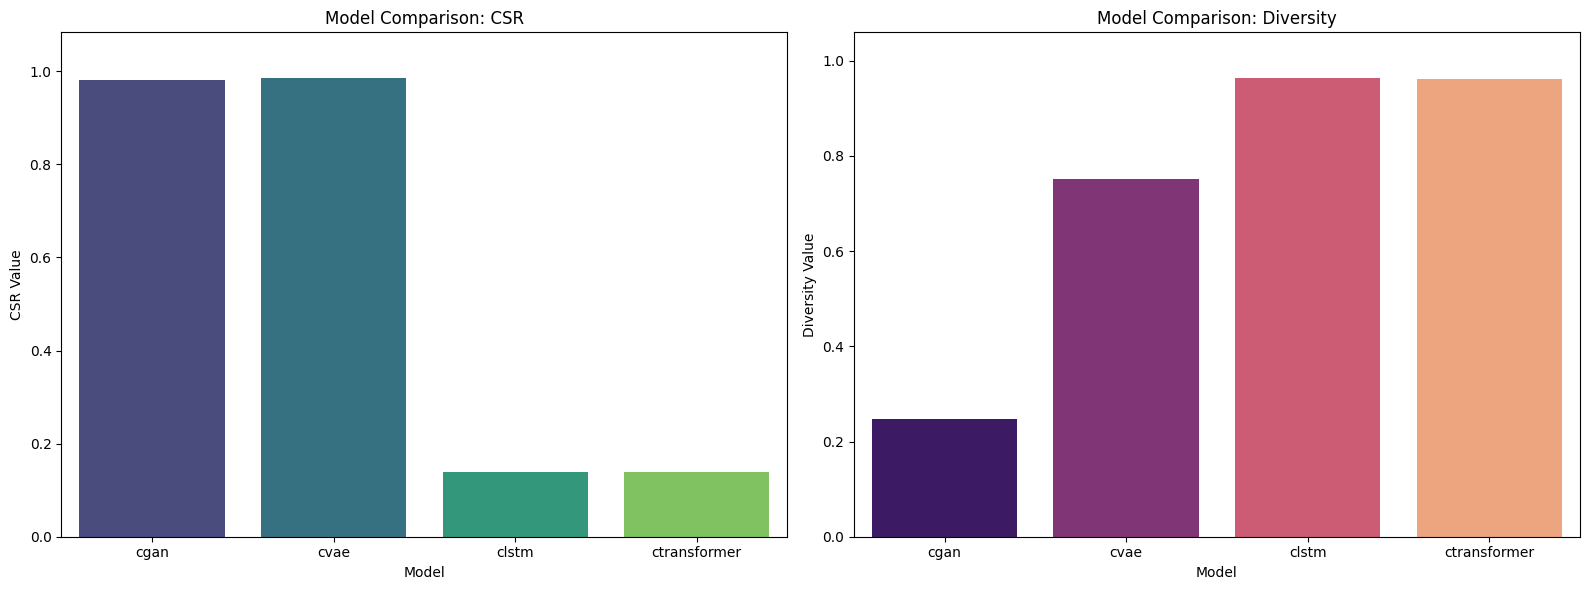

In [23]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the metrics from the JSON file
metrics_path = 'report/metrics.json'
with open(metrics_path, 'r') as f:
    metrics_data = json.load(f)

# Prepare data for plotting
plot_data = []
for model_name, model_metrics in metrics_data.items():
    plot_data.append({
        'Model': model_name,
        'Metric': 'CSR',
        'Value': model_metrics['csr']  # Changed 'CSR' to 'csr'
    })
    plot_data.append({
        'Model': model_name,
        'Metric': 'Diversity',
        'Value': model_metrics['diversity'] # Changed 'div' to 'diversity' to match the actual key
    })

df_metrics = pd.DataFrame(plot_data)

# Create subplots for CSR and Diversity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot CSR
sns.barplot(x='Model', y='Value', data=df_metrics[df_metrics['Metric'] == 'CSR'], ax=axes[0], palette='viridis')
axes[0].set_title('Model Comparison: CSR')
axes[0].set_ylabel('CSR Value')
axes[0].set_ylim(0, df_metrics[df_metrics['Metric'] == 'CSR']['Value'].max() * 1.1)

# Plot Diversity
sns.barplot(x='Model', y='Value', data=df_metrics[df_metrics['Metric'] == 'Diversity'], ax=axes[1], palette='magma')
axes[1].set_title('Model Comparison: Diversity')
axes[1].set_ylabel('Diversity Value')
axes[1].set_ylim(0, df_metrics[df_metrics['Metric'] == 'Diversity']['Value'].max() * 1.1)

plt.tight_layout()
plt.show()